In [24]:
import torch
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
import time

In [25]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [26]:
def load_cifar10(num_train=50000, num_test=10000):
    print("Downloading/Loading CIFAR-10 dataset...")
    (X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.cifar10.load_data()

    # Flatten: (50000, 32, 32, 3) -> (50000, 3072)
    X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
    X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1)

    y_train = y_train.flatten()
    y_test = y_test.flatten()

    X_train_sub = X_train_flat[:num_train]
    y_train_sub = y_train[:num_train]
    X_test_sub = X_test_flat[:num_test]
    y_test_sub = y_test[:num_test]

    # Normalize and Convert to PyTorch Tensors on GPU
    # float32 is standard for GPUs
    X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32, device=device) / 255.0
    y_train_tensor = torch.tensor(y_train_sub, dtype=torch.long, device=device)
    X_test_tensor = torch.tensor(X_test_sub, dtype=torch.float32, device=device) / 255.0
    y_test_tensor = torch.tensor(y_test_sub, dtype=torch.long, device=device)

    print(f"Data on {device}. Train: {X_train_tensor.shape}, Test: {X_test_tensor.shape}")
    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor

In [28]:
class KNN_Image_Torch:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test, batch_size=500):
        num_test = X_test.shape[0]
        y_pred = []

        for i in range(0, num_test, batch_size):
            X_batch = X_test[i : i + batch_size]

            if self.metric == 'euclidean':
                dist_matrix = torch.cdist(X_batch, self.X_train, p=2)

            elif self.metric == 'manhattan':
                dist_matrix = torch.cdist(X_batch, self.X_train, p=1)

            elif self.metric == 'cosine':
                X_batch_norm = torch.nn.functional.normalize(X_batch, p=2, dim=1)
                X_train_norm = torch.nn.functional.normalize(self.X_train, p=2, dim=1)
                similarity = torch.mm(X_batch_norm, X_train_norm.t())
                dist_matrix = 1 - similarity

            elif self.metric == 'minkowski':
                dists = []
                for j in range(X_batch.shape[0]):
                    row_dist = torch.sum(torch.abs(self.X_train - X_batch[j])**3, dim=1)**(1/3)
                    dists.append(row_dist)
                dist_matrix = torch.stack(dists)

            else:
                raise ValueError(f"Metric {self.metric} not implemented for GPU")

            values, indices = torch.topk(dist_matrix, k=self.k, dim=1, largest=False)

            neighbor_labels = self.y_train[indices]

            batch_preds, _ = torch.mode(neighbor_labels, dim=1)
            y_pred.append(batch_preds)

            del dist_matrix, indices, neighbor_labels
            torch.cuda.empty_cache()

        return torch.cat(y_pred).cpu().numpy()

In [29]:
def evaluate_multiclass(y_true, y_pred, num_classes=10):
    accuracy = np.mean(y_true == y_pred)

    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        conf_matrix[t, p] += 1

    precisions = []
    recalls = []

    for c in range(num_classes):
        tp = conf_matrix[c, c]
        fp = conf_matrix[:, c].sum() - tp
        fn = conf_matrix[c, :].sum() - tp

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0

        precisions.append(prec)
        recalls.append(rec)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)

    return accuracy, avg_precision, avg_recall, conf_matrix


In [31]:
def print_cifar_report(best_info):
    """Prints the text summary of the best performing model."""
    config = best_info['config']
    stats = best_info['stats']

    print("\n" + "="*40)
    print(f"BEST RESULT: K={config['k']}, Metric={config['metric']}")
    print("="*40)
    print(f"Accuracy:  {stats['acc']:.4f}")
    print(f"Precision: {stats['prec']:.4f} (Macro Avg)")
    print(f"Recall:    {stats['rec']:.4f} (Macro Avg)")
    print("Confusion Matrix:")
    print(stats['cm'])


In [32]:
def plot_cifar_accuracy(results, k_values):
    """Plots the K vs Accuracy graph for different metrics."""
    plt.figure(figsize=(10, 6))
    for metric, accs in results.items():
        plt.plot(k_values, accs, marker='o', label=metric)

    plt.title('CIFAR-10: Accuracy vs K for different Metrics')
    plt.xlabel('K (Number of Neighbors)')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [33]:
def plot_confusion_matrix_heatmap(best_info):
    """Visualizes the confusion matrix as a heatmap."""
    stats = best_info['stats']
    config = best_info['config']
    cm = stats['cm']

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (K={config['k']}, {config['metric']})")
    plt.colorbar()

    # Axis labels
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add numbers to squares
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [34]:
def task2():
    X_train, y_train, X_test, y_test = load_cifar10(num_train=50000, num_test=10000)

    y_test_cpu = y_test.cpu().numpy()

    k_values = [3, 4, 9, 20]
    metrics = ['euclidean', 'manhattan', 'cosine']

    results = {}
    best_acc = -1
    best_info = {}

    print("\n--- Starting GPU Experiments ---")

    for metric in metrics:
        acc_list = []
        print(f"\nTesting Metric: {metric}")

        for k in k_values:
            start_time = time.time()

            knn = KNN_Image_Torch(k=k, distance_metric=metric)
            knn.fit(X_train, y_train)

            preds = knn.predict(X_test, batch_size=200)

            acc, prec, rec, cm = evaluate_multiclass(y_test_cpu, preds)
            acc_list.append(acc)

            elapsed = time.time() - start_time
            print(f"  K={k}: Accuracy={acc:.4f} (Time: {elapsed:.2f}s)")

            if acc > best_acc:
                best_acc = acc
                best_info = {
                    'config': {'k': k, 'metric': metric},
                    'stats': {'acc': acc, 'prec': prec, 'rec': rec, 'cm': cm}
                }

        results[metric] = acc_list

    print_cifar_report(best_info)
    plot_cifar_accuracy(results, k_values)
    plot_confusion_matrix_heatmap(best_info)

Downloading/Loading CIFAR-10 dataset...
Data on cuda. Train: torch.Size([50000, 3072]), Test: torch.Size([10000, 3072])

--- Starting GPU Experiments ---

Testing Metric: euclidean
  K=3: Accuracy=0.3302 (Time: 2.01s)
  K=4: Accuracy=0.3400 (Time: 1.96s)
  K=9: Accuracy=0.3463 (Time: 1.99s)
  K=20: Accuracy=0.3415 (Time: 1.98s)

Testing Metric: manhattan
  K=3: Accuracy=0.3625 (Time: 25.08s)
  K=4: Accuracy=0.3684 (Time: 25.65s)
  K=9: Accuracy=0.3864 (Time: 26.21s)
  K=20: Accuracy=0.3761 (Time: 25.92s)

Testing Metric: cosine
  K=3: Accuracy=0.3556 (Time: 1.42s)
  K=4: Accuracy=0.3604 (Time: 1.43s)
  K=9: Accuracy=0.3695 (Time: 1.42s)
  K=20: Accuracy=0.3571 (Time: 1.41s)

BEST RESULT: K=9, Metric=manhattan
Accuracy:  0.3864
Precision: 0.4643 (Macro Avg)
Recall:    0.3864 (Macro Avg)
Confusion Matrix:
[[531   4 107  13  51   4  30   5 242  13]
 [ 81 227 104  42 148  29  61  13 237  58]
 [104   3 422  44 237  28  82  13  61   6]
 [ 66   5 169 193 204 108 151  26  66  12]
 [ 65   2 235

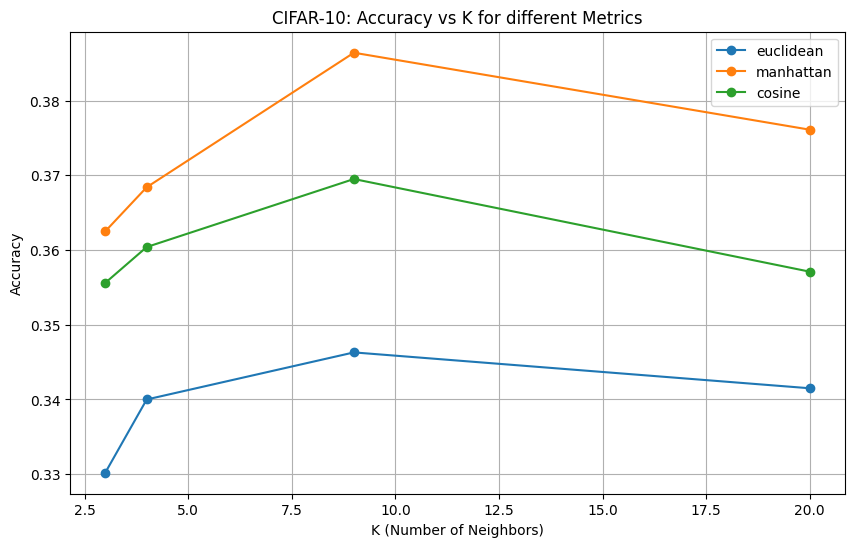

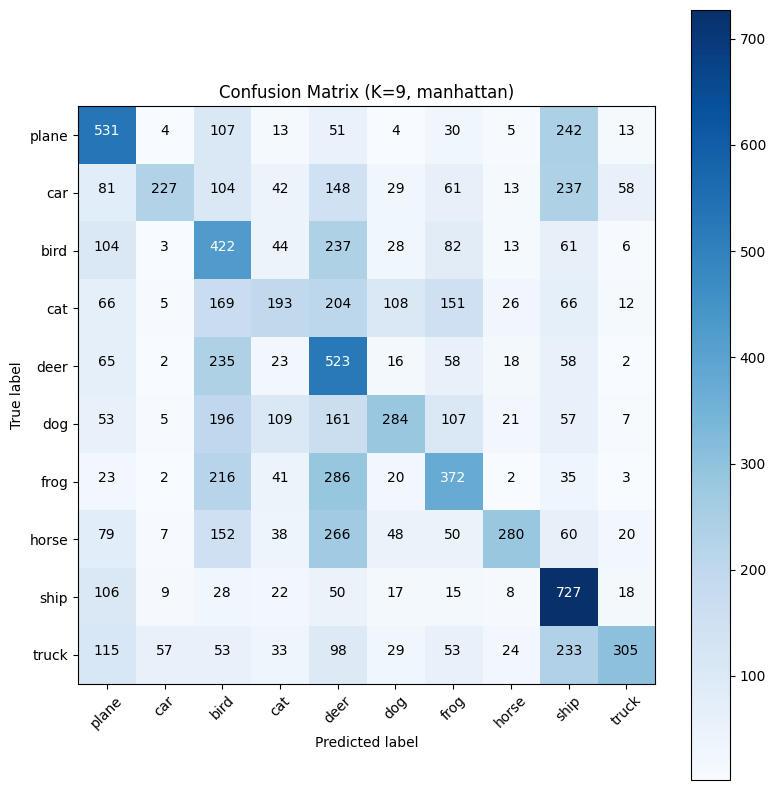

In [35]:
if __name__ == "__main__":
    task2()